# Assignment 4

Deadline: 13.05.2026, 12:00 CET

**Submitted by:** Luca Francesco Besomi, 20-206-769, lucafrancesco.besomi@uzh.ch; Francesco Carlo Filippo Orsingher, 21-986-971, francescocarlofilippo.orsingher@uzh.ch; Devin Liam Rohr, 16-454-753, devinliam.rohr@uzh.ch; Tamas Terner, 19-755-495, tamas.terner@uzh.ch

In [1]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import statsmodels.api as sm    # for regression analysis in 1.c) (or any other regression library you prefer)

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.abspath(''))
src_path = os.path.join(project_root, 'src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from estimation.covariance import Covariance
from optimization.optimization import PercentilePortfolio
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

c:\Users\Devin\Desktop\UZH\qpmwp-course\src\estimation\black_litterman.py:34: SyntaxWarning: invalid escape sequence '\S'
  """


## Constants

In [2]:
PATH_TO_DATA = os.path.join(os.getcwd(), '..', 'data') + os.sep      # <change this to your path to data>
SAVE_PATH = os.path.join(os.getcwd(), '..', 'results') + os.sep     # <change this to your path where you want to store the backtest>

## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [3]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path='../data/')

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(market_data=market_data, jkp_data=jkp_data)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = spi

## Define a grid or rebalancing dates

In [4]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## 1. a) Define the key data fields that characterize a factor theme

- Beside the pre-defined fields, choose three factor themes from table 9 of the Global Factor Data Documentation (See https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf, Section 10.) and add the individual fields.

**(2 points)**

In [8]:
JKP_FIELDS_QUALITY = [
    'at_turnover',
    'cop_at',
    'cop_atl1',
    'dgp_dsale',
    'gp_at',
    'gp_atl1',
    'mispricing_perf',
    'ni_inc8q',
    'niq_at',
    'op_at',
    'op_atl1',
    'opex_at',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'sale_bev',
]

JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

# <add the name of the factor theme here>
# Low Risk (Table 9: Low Risk / Low Beta)
JKP_FIELDS_LOW_RISK = [
    'beta_60m',
    'betadown_252d',
    'ivol_capm_21d',
    'ivol_capm_252d',
    'ivol_ff3_21d',
    'rvol_21d',       
    'rmax1_21d',
    'turnover_126d',
]

# <add the name of the factor theme here>
# Investment (Table 9: Investment)
JKP_FIELDS_INVESTMENT = [
    'capx_gr1',
    'capx_gr2',
    'capx_gr3',
    'inv_gr1',
    'be_gr1a',
    'noa_gr1a',
    'ppeinv_gr1a',    
    'emp_gr1',
]
# <add the name of the factor theme here>
# Accruals (Table 9: Accruals)
JKP_FIELDS_ACCRUALS = [
    'oaccruals_at',
    'oaccruals_ni',
    'taccruals_at',
    'taccruals_ni',
    'cowc_gr1a',
    'coa_gr1a',
    'col_gr1a',
]


JKP_FIELDS = {
    'quality': JKP_FIELDS_QUALITY,
    'value': JKP_FIELDS_VALUE,
    'momentum': JKP_FIELDS_MOMENTUM,
    'low_risk':   JKP_FIELDS_LOW_RISK,
    'investment': JKP_FIELDS_INVESTMENT,
    'accruals':   JKP_FIELDS_ACCRUALS,
}

## 1. b) Factor series for each factor theme.

- For each factor theme, run a backtest for the top‑quintile portfolio and a second backtest for the bottom‑quintile portfolio.

- Simulate the return streams for both backtests and define the factor series as a long-short portfolio going long the top quintile portfolio and going short the bottom quintile portfolio.

- Plot the cumulative returns of the top quintile portfolio, the bottom quintile portfolio, the long-short factor portfolio, and the benchmark series.

**(8 points)**

In [10]:
# Check that all fields are present in the jkp data
for theme_name, fields in JKP_FIELDS.items():
    missing = [f for f in fields if f not in data.jkp_data.columns]
    if missing:
        print(f"{theme_name}: missing {missing}")
    else:
        print(f"{theme_name}: all fields OK")


quality: all fields OK
value: all fields OK
momentum: all fields OK
low_risk: all fields OK
investment: all fields OK
accruals: all fields OK


Running backtests for theme: 'quality' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_24420\1637002582.py:75: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


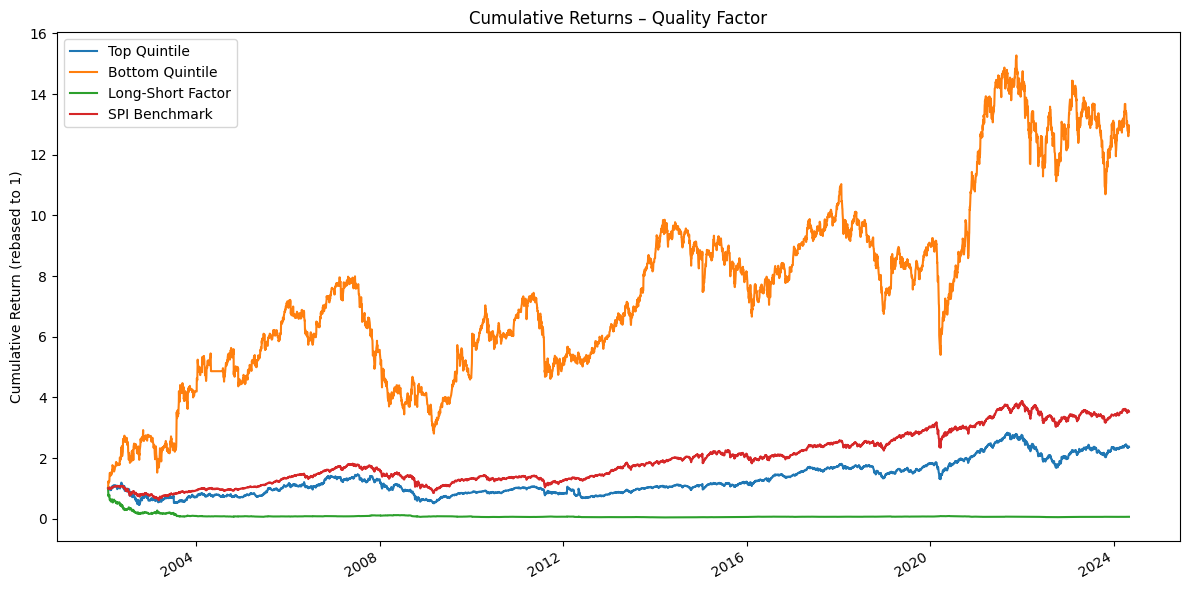

Running backtests for theme: 'value' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_24420\1637002582.py:75: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


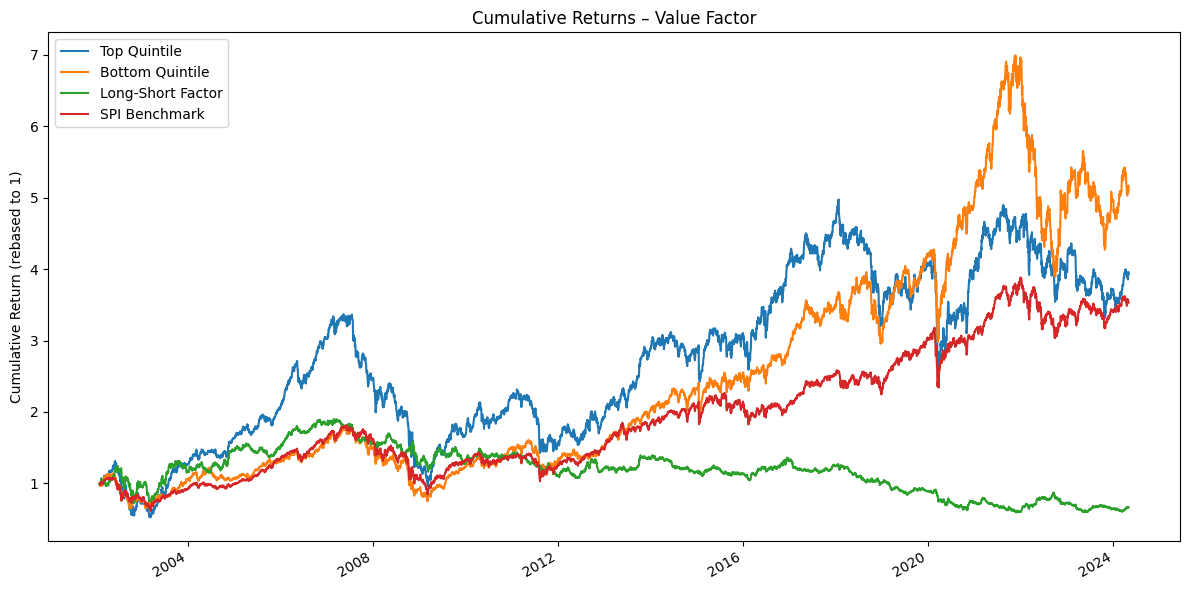

Running backtests for theme: 'momentum' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_24420\1637002582.py:75: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


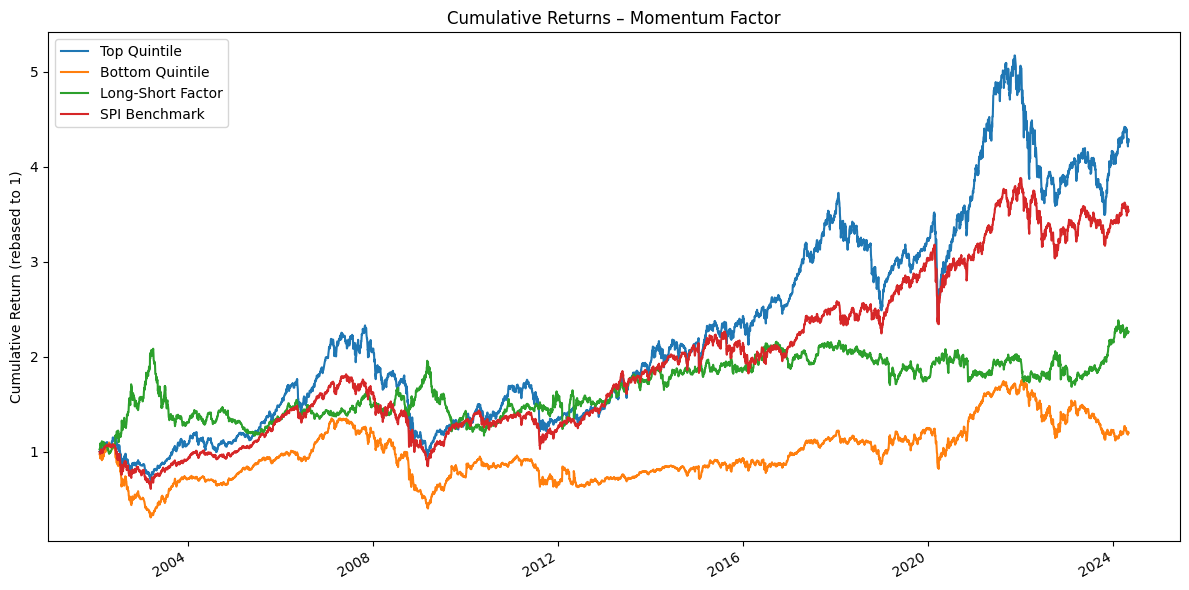

Running backtests for theme: 'low_risk' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_24420\1637002582.py:75: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


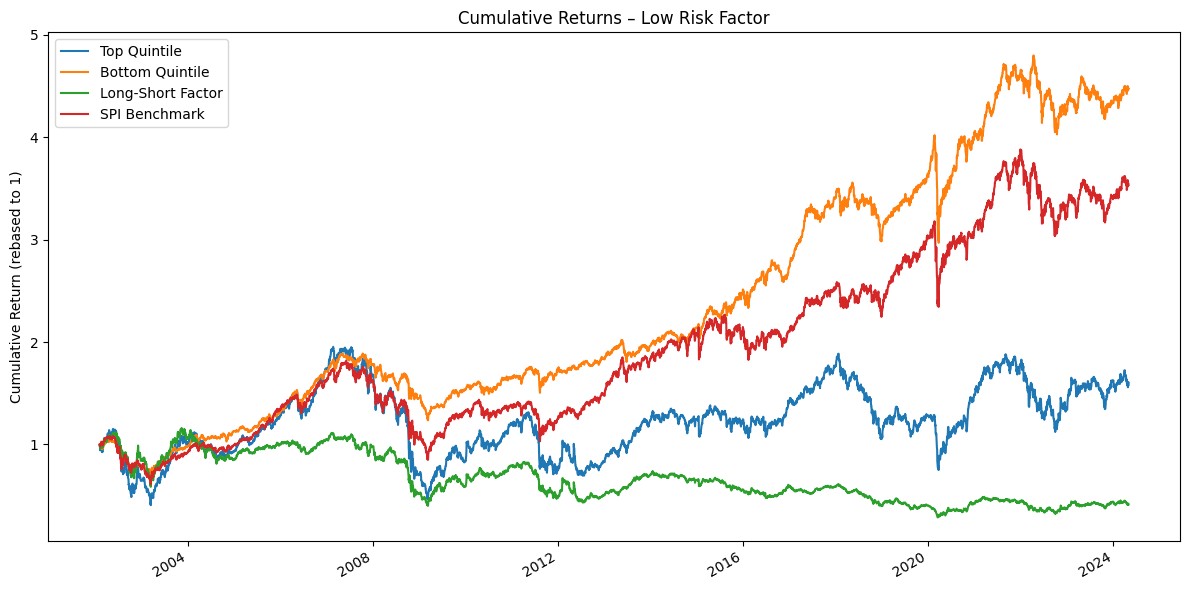

Running backtests for theme: 'investment' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_24420\1637002582.py:75: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


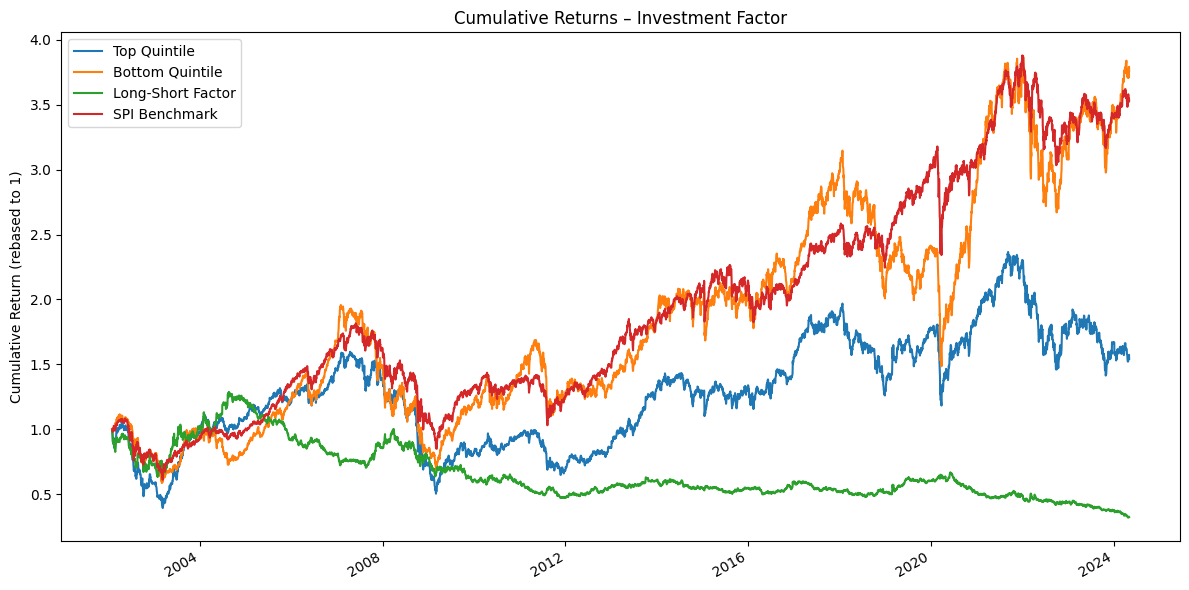

Running backtests for theme: 'accruals' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_24420\1637002582.py:75: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


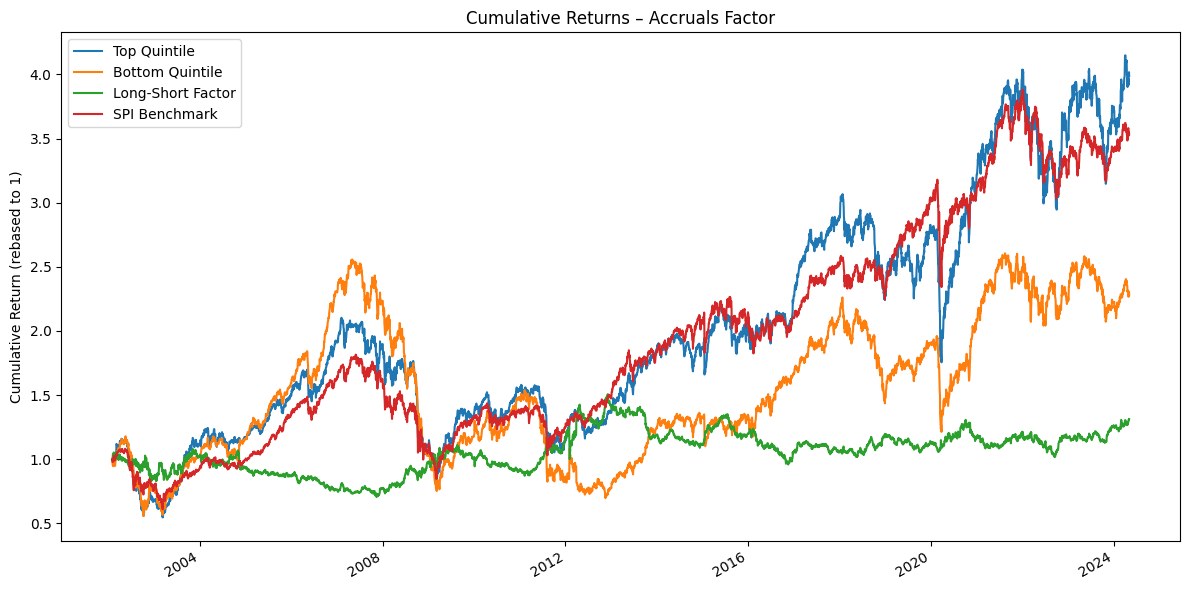

In [11]:
import matplotlib.pyplot as plt

return_series = data.get_return_series(weekdays_only=False)
factor_simulations = {}

for theme_name, fields in JKP_FIELDS.items():
    print(f"Running backtests for theme: '{theme_name}' ...")

    score_weights = {f: 1 / len(fields) for f in fields}

    selection_ibs = {
        'gaps': SelectionItemBuilder(
            bibfn=bibfn_selection_gaps,
            width=365 * 3,
            n_days=10,
        ),
        'min_volume': SelectionItemBuilder(
            bibfn=bibfn_selection_min_volume,
            width=365 * 3,
            min_volume=500_000,
            agg_fn=np.median,
        ),
        'jkp_data_scores': SelectionItemBuilder(
            bibfn=bibfn_selection_jkp_data_scores,
            fields=fields,
        ),
    }

    optimization_ibs = {
        'scores': OptimizationItemBuilder(
            bibfn=bibfn_scores,
            fields=fields,
        ),
    }

    # One BacktestService shared for both quintiles of this theme
    bs_theme = BacktestService(
        data=data,
        selection_item_builders=selection_ibs,
        optimization_item_builders=optimization_ibs,
        rebdates=rebdates,
    )
    bs_theme.settings['quiet'] = True

    # Top quintile (long leg)
    bs_theme.optimization = PercentilePortfolio(
        score_weights=score_weights,
        percentile=80,
        sign='>=',
    )
    bt_top = Backtest()
    bt_top.run(bs=bs_theme)
    sim_top = bt_top.strategy.simulate(return_series=return_series, fc=0, vc=0)

    # Bottom quintile (short leg)
    bs_theme.optimization = PercentilePortfolio(
        score_weights=score_weights,
        percentile=20,
        sign='<=',
    )
    bt_bottom = Backtest()
    bt_bottom.run(bs=bs_theme)
    sim_bottom = bt_bottom.strategy.simulate(return_series=return_series, fc=0, vc=0)

    # Long-short factor series
    sim_factor = sim_top - sim_bottom

    factor_simulations[theme_name] = {
        'top':    sim_top,
        'bottom': sim_bottom,
        'factor': sim_factor,
    }

    # Plot cumulative returns
    plot_df = pd.concat({
        'Top Quintile':     sim_top,
        'Bottom Quintile':  sim_bottom,
        'Long-Short Factor': sim_factor,
        'SPI Benchmark':    data.bm_series,
    }, axis=1).dropna()

    (1 + plot_df).cumprod().plot(
        title=f'Cumulative Returns – {theme_name.replace("_", " ").title()} Factor',
        figsize=(12, 6),
    )
    plt.ylabel('Cumulative Return (rebased to 1)')
    plt.tight_layout()
    plt.show()


## 1. c) Factor analysis

- First, compute a factor-mix return series by averaging the returns of the top-quintile portfolio simulations that you have computed above. 

- Second, run an ordinary least squares regression of y on X, where y is your factor-mix series and X contains i) a constant, ii) the SPI return series, and iii) the factor return series computed in 1.b).

- Use monthly returns.

- Print a summary table of the regression output

**(5 points)**

In [12]:
# Factor-mix: equal-weighted average of all top-quintile return streams
top_df = pd.concat(
    {name: d['top'] for name, d in factor_simulations.items()},
    axis=1,
).dropna()
factor_mix = top_df.mean(axis=1)

# Resample daily returns to monthly
def to_monthly(series):
    return ((1 + series).resample('ME').prod() - 1).dropna()

y              = to_monthly(factor_mix)
spi_monthly    = to_monthly(data.bm_series)
factor_ls_monthly = {name: to_monthly(d['factor']) for name, d in factor_simulations.items()}

# Align all series
X = pd.concat({'spi': spi_monthly, **factor_ls_monthly}, axis=1).dropna()
y = y.reindex(X.index).dropna()
X = X.loc[y.index]
X = sm.add_constant(X)

# OLS regression: factor_mix ~ const + SPI + factor_ls (one per theme)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     412.7
Date:                Sun, 03 May 2026   Prob (F-statistic):          1.60e-136
Time:                        15:13:48   Log-Likelihood:                 712.91
No. Observations:                 267   AIC:                            -1410.
Df Residuals:                     259   BIC:                            -1381.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.001      2.211      0.0